# Density Estimation

## Roadmap

1. Create a kernel density estimator $\hat{f}_h(x)$
2. Implement the Silverman plug-in bandwidth $h$
3. Contrast the KDE's small sample properties with the ECDF's small sample properties

## Where we're headed

Five students turn in a quiz scored out of 10: $5$, $7$, $7$, $8$, $10$ (two of them tied at $7$).

A sixth quiz is about to land in your inbox. Before you look at it, how confident should you be about where its score will fall? 

**Why can't the ECDF just answer this?** You already know how to build $\hat F$ from these five scores, and it's a perfectly good answer to "what fraction of submissions so far scored at or below $x$." But it can't tell you how *likely* a new, not-yet-seen score is to land near any particular value. You want something that spreads plausibility out *around* the scores you've seen, not just counts up to them.

That "something" is a **density** -- some $f(x)$ describing how likely a new observation is to land near any given $x$. You've seen densities with the **PDF**, but here we want to build one entirely from the five scores you have, with no assumption about what family of distribution they came from. That's what today is about: kernel density estimation.

We'll build the formula next, working through **this exact example** the whole way -- so keep `5, 7, 7, 8, 10` in mind, we'll come straight back to it.

## 1. Estimating $f(x)$ as a moving window
- Intuitively, we are estimating the "probability" that $X$ lands in a small neighborhood around $x$, $ x-h < X < x+h $
- The corresponding sample question is, "What is the sample proportion of observations in a neighborhood, from $x-h$ to $x+h$?"
- We call that $h$ the **bandwidth**
- This is a "moving window histogram" called a **kernel density estimator**

## Example: Heart Failure and Age

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [2]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator (Blocky)')
    plt.show()
    return x_grid, f_hat

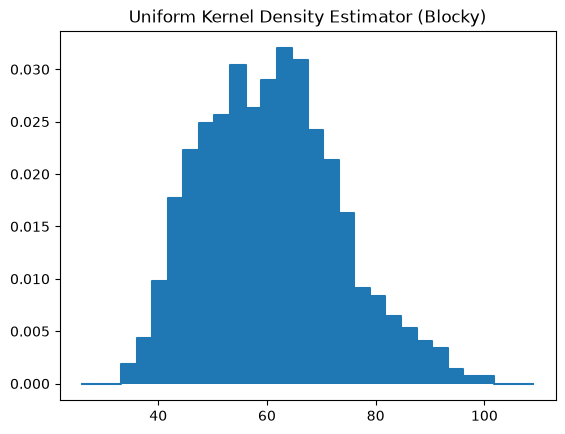

(array([ 26.02526458,  28.88559116,  31.74591774,  34.60624432,
         37.4665709 ,  40.32689748,  43.18722406,  46.04755064,
         48.90787722,  51.7682038 ,  54.62853039,  57.48885697,
         60.34918355,  63.20951013,  66.06983671,  68.93016329,
         71.79048987,  74.65081645,  77.51114303,  80.37146961,
         83.2317962 ,  86.09212278,  88.95244936,  91.81277594,
         94.67310252,  97.5334291 , 100.39375568, 103.25408226,
        106.11440884, 108.97473542]),
 array([0.        , 0.        , 0.        , 0.00191459, 0.00430782,
        0.00981226, 0.01770993, 0.02225708, 0.02488964, 0.02560761,
        0.03039408, 0.02632558, 0.02895813, 0.03206934, 0.03087272,
        0.02417167, 0.02129979, 0.01627399, 0.00909429, 0.00837632,
        0.00646173, 0.00526512, 0.0040685 , 0.00335053, 0.00143594,
        0.00071797, 0.00071797, 0.        , 0.        , 0.        ]))

In [3]:
kde(df['age'])

[Text(0.5, 1.0, 'Gaussian KDE (Smooth)')]

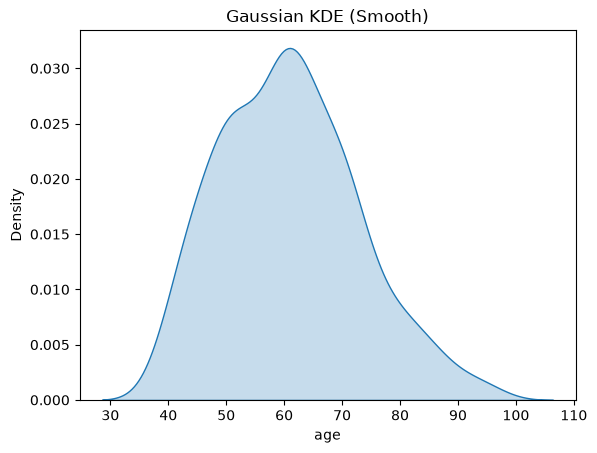

In [4]:
sns.kdeplot( data = df, x = 'age', fill = True).set(title='Gaussian KDE (Smooth)')

## Estimating the PDF
- The pdf at $x$ is roughly, "The probability that $X$ falls in a window around $x$, as the window/bandwidth $h$ shrinks"
- Let's estimate that with: "The sample proportion of observations in a window of length $2h$ around $x$, as the bandwidth goes to zero",
$$
\hat{f}(x) = \dfrac{\text{ Number of observations $i$ within $\pm h$ of $x$} }{n \times 2h} 
$$
- This gives us something like a histogram, called a **(uniform) kernel density estimator**:
$$
\hat{f}_h(x) = \frac{ \sum_{i=1}^n  \mathbb{I}\{ |x_i-x|<h \} }{2nh}
$$

Two ways to arrive at the same formula end up mattering later, so it's worth naming both now.

**Route 1 -- count and divide.** That's exactly what we just did: a proportion, Week 4's object again, with a new event (`x_i` in the window).

**Route 2 -- the slope of the ECDF.** We know $f = F'$. Take a *secant* of the ECDF, the difference quotient you'd take right before letting the gap close:

$$
\hat f_h(x) = \frac{\hat F(x+h) - \hat F(x-h)}{2h}
$$

Expand both ECDFs and the algebra collapses to exactly the same formula as Route 1 -- for each $i$, the numerator's bracket is 1 exactly when $x_i$ is in the window $(x-h, x+h]$. **Same estimator, two questions.** The `2h` is what turns a raw proportion into a *rate* -- density is a rate, not a probability, and this is where that shows up.

**Worked, on our running example.** `X = [5, 7, 7, 8, 10]`, so $n=5$. Take $h = 1.5$ and evaluate at $x=7$:

$$
\hat f_h(7) = \frac{\text{number of } x_i \text{ with } |7-x_i|<1.5}{2 \times 5 \times 1.5}
$$

Check each point: $|7-5|=2$ (out), $|7-7|=0$ (in, *twice* -- both students tied at 7), $|7-8|=1$ (in), $|7-10|=3$ (out). That's 3 observations in the window, so

$$
\hat f_h(7) = \frac{3}{15} = 0.2
$$

Hold onto this number -- it's one point on the curve you'll build by hand in the board exercise below.

- Why $2h$? The length of the interval $(x-h, x+h)$ is $x-h-(x-h)=2h$, and we divide to normalize the "width" of the window to 1

## Example on the board

Now that the formula is in hand, work these out by hand -- build a table of breakpoints (every $x_i \pm h$), and in each interval between breakpoints, count how many windows cover it. The height there is `count / (2nh)`.

**Problem 1.** The running example from the top of this notebook: $X = [5,\ 7,\ 7,\ 8,\ 10]$, $h = 1.5$. You already computed one point of $\hat f_h(x)$ above ($\hat f_h(7) = 0.2$) -- now build out the *whole* piecewise curve, not just that one point.


## 2. Measurement error: the KDE as an average of bumps

A second way to build the same idea, useful if the window story feels arbitrary. Imagine each $x_i$ is really measured *with noise*: a random variable centered at $x_i$, uniform on $[x_i-h, x_i+h]$, with density $1/2h$. Call that density $f_{i,h}(x)$.

Plot the densities of all $n$ of those noisy measurements and average them, and you get the KDE back:

$$
\hat f_h(x) = \frac{1}{n}\sum_{i=1}^n f_{i,h}(x)
$$

A rectangular bump gives back exactly the uniform-kernel estimator above; a Gaussian bump gives the smooth version later in this notebook.

<img src="./src/kde_build.png" width="750px">

---
## On the board

**Problem 2.** Five customers' wait times at a coffee shop, in minutes: $X = [2,\ 4,\ 5,\ 6,\ 9]$. Use $h = 1.5$. Sketch $\hat f_h(x)$. (Careful -- with this $h$, one stretch of the line is covered by *three* windows at once, not just two -- find it.)

---

### Over-fitting and under-fitting

Watch what happens as $h$ moves. Small $h$ averages over few points -- the curve chases individual observations (**high variance, low bias**). Large $h$ averages over a wide neighborhood -- the curve barely moves if you resample, but it smooths away real features (**low variance, high bias**). This is the bias-variance trade-off, and it recurs for the rest of the course.

In [ ]:
def silverman_bandwidth(X, kernel="uniform"):
    """Silverman's rule-of-thumb bandwidth. `kernel` selects the constant."""
    const = {"uniform": 1.84, "gaussian": 1.06}[kernel]
    return const * np.std(X) * len(X) ** (-0.2)


def kde_grid(X, h, pad=2.0, K=200):
    """The evaluation grid shared by every estimator below."""
    X = np.asarray(X)
    return np.linspace(X.min() - pad * h, X.max() + pad * h, K)


def uniform_kde(X, grid, h):
    """f_hat_h(x) on `grid`, uniform kernel. Pure computation, no plotting."""
    X = np.asarray(X)
    n = len(X)
    I = np.abs(grid[:, None] - X[None, :]) < h
    return I.sum(axis=1) / (2 * n * h)


def gaussian_kde(X, grid, h):
    """f_hat_h(x) on `grid`, Gaussian kernel."""
    X = np.asarray(X)
    n = len(X)
    Z = (grid[:, None] - X[None, :]) / h
    phi = np.exp(-Z**2 / 2) / np.sqrt(2 * np.pi)
    return phi.sum(axis=1) / (n * h)


def plot_density(grid, f_hat, **kwargs):
    """One shared plotting routine, reused for both single curves and bump stacks."""
    plt.step(grid, f_hat, where="mid", **kwargs)

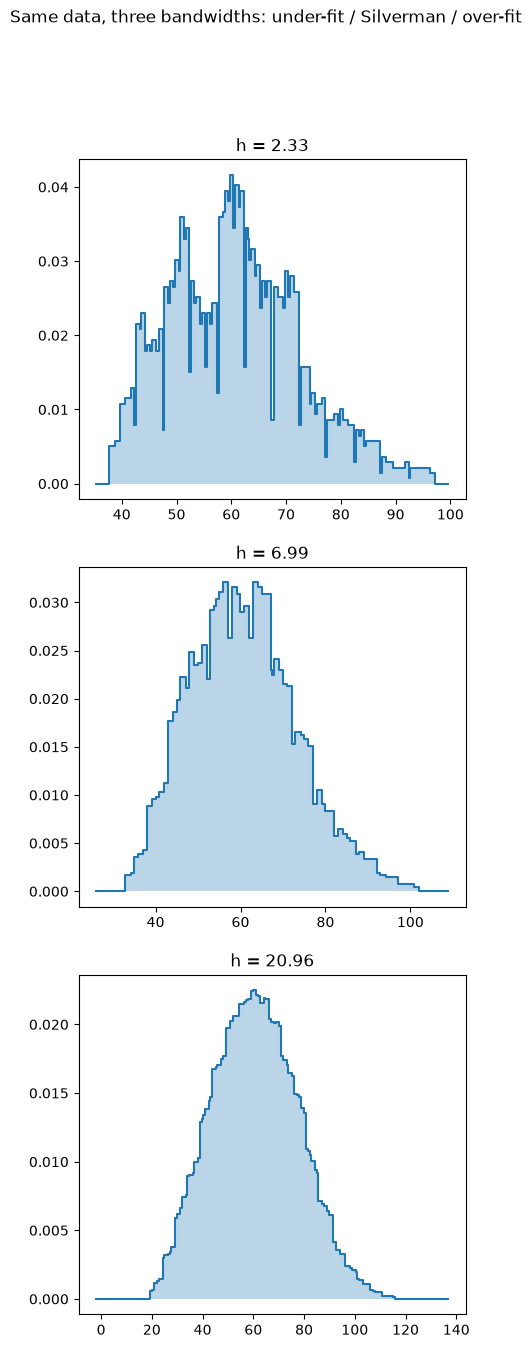

In [ ]:
X = df["age"].to_numpy(dtype=float)
h_default = silverman_bandwidth(X, "uniform")

fig, axes = plt.subplots(3,1, figsize=(5, 15), sharex=False)
for ax, h in zip(axes, [h_default / 3, h_default, h_default * 3]):
    grid = kde_grid(X, h)
    f_hat = uniform_kde(X, grid, h)
    ax.step(grid, f_hat, where="mid")
    ax.fill_between(grid, f_hat, step="mid", alpha=0.3)
    ax.set_title(f"h = {h:.2f}")
plt.suptitle("Same data, three bandwidths: under-fit / Silverman / over-fit")
plt.show()

## Choosing h: Silverman's rule for a plug-in Bandwidth
- There are data-driven methods to pick the bandwidth $h$ (likelihood or least squares cross validation), there is a standard and convenient choice called **Silverman's rule-of-thumb (for the uniform kernel)**:
$$
h_u = 1.84 \times \text{sd}(X) \times n^{-1/5},
$$
- We do want to investigate different choices of $h$, but having a standard starting point is very, very convenient

## Building it on real data

The code below is organized around three small, separately-testable pieces instead of one function that computes and plots at once: a bandwidth rule, a pure computation of $\hat f_h$ on a grid (no plotting), and a plotting helper. That split is what lets the "stack of bumps" demo below reuse the exact same bandwidth/grid logic as the main estimator, instead of recomputing it by hand a second time.

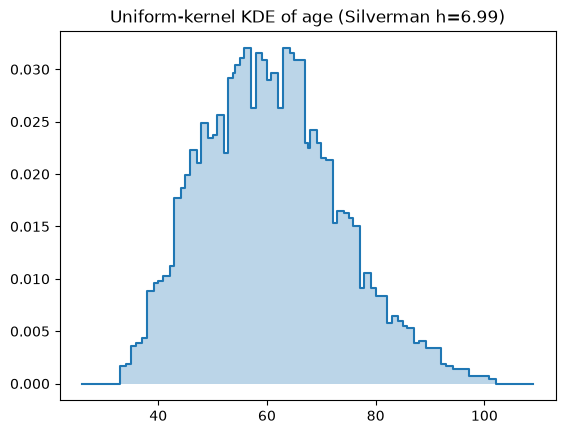

age: area under f_hat = 1.0102


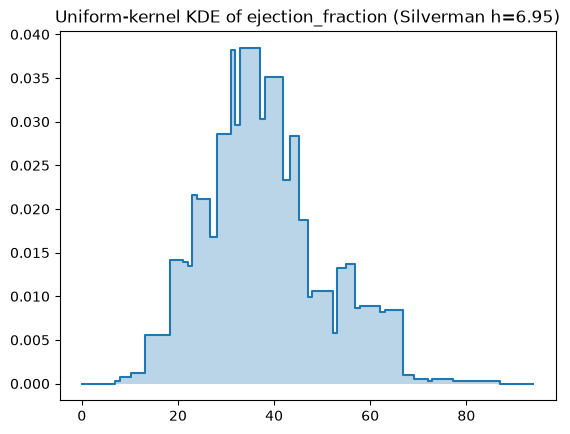

ejection_fraction: area under f_hat = 0.9993


In [6]:
# Uniform-kernel KDE on two real columns, using the shared helpers.
for col in ["age", "ejection_fraction"]:
    X = df[col].to_numpy(dtype=float)
    h = silverman_bandwidth(X, "uniform")
    grid = kde_grid(X, h)
    f_hat = uniform_kde(X, grid, h)

    plt.figure()
    plot_density(grid, f_hat)
    plt.fill_between(grid, f_hat, step="mid", alpha=0.3)
    plt.title(f"Uniform-kernel KDE of {col} (Silverman h={h:.3g})")
    plt.show()

    print(f"{col}: area under f_hat = {np.trapezoid(f_hat, grid):.4f}")

## Example: Ejection Fraction

In [7]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    print(f'Plug-in Bandwidth Estimated is: {h_u:2f}')
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.show()
    return x_grid, f_hat

Plug-in Bandwidth Estimated is: 6.952141


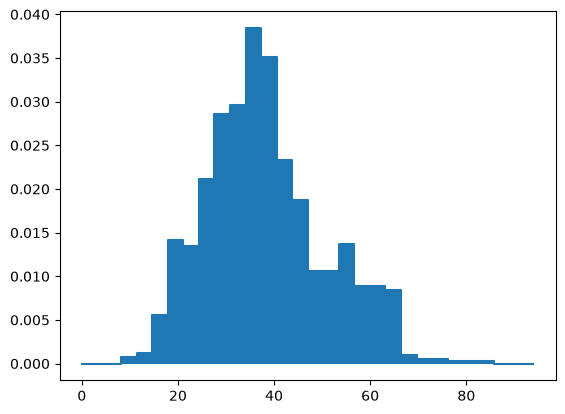

(array([ 0.09571897,  3.33049697,  6.56527498,  9.80005298, 13.03483098,
        16.26960898, 19.50438698, 22.73916499, 25.97394299, 29.20872099,
        32.44349899, 35.67827699, 38.913055  , 42.147833  , 45.382611  ,
        48.617389  , 51.852167  , 55.086945  , 58.32172301, 61.55650101,
        64.79127901, 68.02605701, 71.26083501, 74.49561302, 77.73039102,
        80.96516902, 84.19994702, 87.43472502, 90.66950303, 93.90428103]),
 array([0.        , 0.        , 0.        , 0.00072161, 0.00120268,
        0.00553233, 0.01419163, 0.01347002, 0.02116718, 0.0286238 ,
        0.02958594, 0.03848578, 0.03511827, 0.023332  , 0.01876182,
        0.01058359, 0.01058359, 0.01371056, 0.00889984, 0.00889984,
        0.00841876, 0.00096214, 0.00048107, 0.00048107, 0.00024054,
        0.00024054, 0.00024054, 0.        , 0.        , 0.        ]))

In [8]:
kde(df['ejection_fraction'])

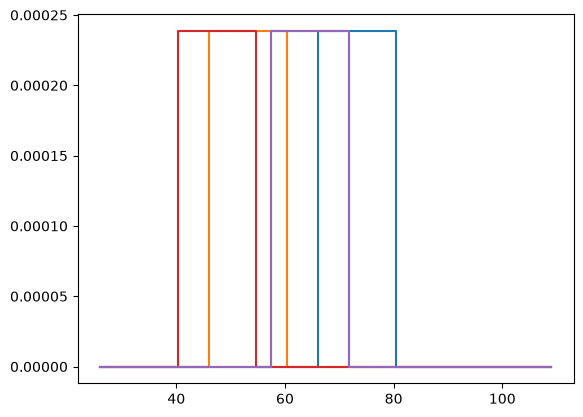

Plug-in Bandwidth Estimated is: 16.874549


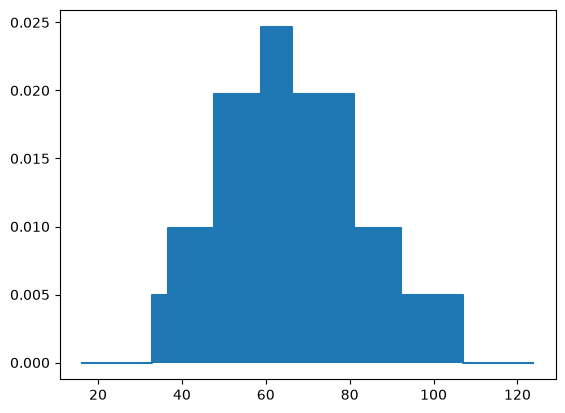

(array([ 16.25090255,  19.95773686,  23.66457117,  27.37140547,
         31.07823978,  34.78507409,  38.49190839,  42.1987427 ,
         45.90557701,  49.61241131,  53.31924562,  57.02607993,
         60.73291423,  64.43974854,  68.14658285,  71.85341715,
         75.56025146,  79.26708577,  82.97392007,  86.68075438,
         90.38758869,  94.09442299,  97.8012573 , 101.50809161,
        105.21492591, 108.92176022, 112.62859453, 116.33542883,
        120.04226314, 123.74909745]),
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.0049384 , 0.00987681, 0.00987681, 0.00987681, 0.01975361,
        0.01975361, 0.01975361, 0.02469202, 0.02469202, 0.01975361,
        0.01975361, 0.01975361, 0.01975361, 0.00987681, 0.00987681,
        0.00987681, 0.0049384 , 0.0049384 , 0.0049384 , 0.0049384 ,
        0.        , 0.        , 0.        , 0.        , 0.        ]))

In [9]:
J = 5
X = df['age']
n = len(X)
h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, 30) # Create a grid to plot

for i in range(J):
    I_i = np.abs( x_grid[:,None] - X[i]) < h_u # Broadcast the indicator
    f_i = np.sum(I_i,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_i,where='pre')
plt.show()

kde( df.loc[:J,'age'] )

## 3. Bias: is the KDE unbiased?

Take the expectation of Route 2's estimator. Expectation passes through, and $E[\hat F] = F$:

$$
E[\hat f_h(x)] = \frac{F(x+h) - F(x-h)}{2h}
$$

That's a difference quotient of the *true* CDF -- not $f(x)$, but something that becomes $f(x)$ as $h \to 0$:

$$
\lim_{h \to 0} E[\hat f_h(x)] = F'(x) = f(x)
$$

<img src="./src/secant.png" width="750px">

### Biased, but consistent

Silverman's $h$ is **not** zero -- it's proportional to $n^{-1/5}$. So for any actual sample, $E[\hat f_h(x)] \ne f(x)$: the KDE is **biased**. But because $h_n \to 0$ as $n$ grows, the bias also shrinks: the KDE is a **consistent** estimator of $f(x)$, just not an unbiased one -- the first estimator in the course where those two properties come apart.

## Expectation of the KDE
- What happens if we take the expectation of the KDE? The ECDF is unbiased, so we know:
$$
\mathbb{E}_X[\hat{f}_{X,h}(x)] = \mathbb{E}_X \left[ \dfrac{\hat{F}_X(x+h)- \hat{F}_X(x-h)}{2h} \right] = \dfrac{F_X(x+h)- F_X(x-h)}{2h}
$$
- This is not quite the derivative of the CDF, which would be the PDF? But if we take the limit with respect to $h$, we get
$$
\lim_{h \rightarrow 0} \mathbb{E}_X[\hat{f}_{X,h}(x)] = F_X'(x)
$$
- This quantity, $F_X'(x)$ is defined as the probability density function $f_X(x)$: The KDE is roughly estimating the PDF, as the bandwidth $h$ goes to zero


## The KDE is Biased, but Consistent
- We know from our earlier calculations that
$$
\lim_{h \rightarrow 0} \mathbb{E}_X[\hat{f}_{X,h}(x)] = F_X'(x)
$$
- But since we are typically using the Silverman plug-in, that $h$ is not zero: It's proportional to $ 1/n^{1/5}$
- The KDE is **biased**: It is not equal to the pdf $f(x)$ in expectation
- But because $h_n \rightarrow 0$ as $n$ gets large, the bias also tends to zero as $h_n\rightarrow 0$
- The KDE is a **consistent estimator** of $f_X(x)$, since the estimate tends to the truth as the sample size gets large

## 4. Different Kernels: using a smoother Gaussian kernel 
- Instead of using the uniform density for "measurement error", you can use a standard normal/Gaussian:
$$
\hat{f}_h(x) = \dfrac{1}{nh} \sum_{i=1}^n \dfrac{1}{\sqrt{2\pi}} \exp \left( -\frac{1}{2} \left( \dfrac{x_i-x}{h}\right)^2\right)
$$
with bandwidth plug-in
$$
h = 1.06 \times \text{SD}(X) \times n^{-.2}
$$
- This is the default for plotting software, but it's a choice you should be conscious of
- There is an entire field of **non-parametric estimation** that studies how to estimate densities/distributions this way

# 5. Example on real data

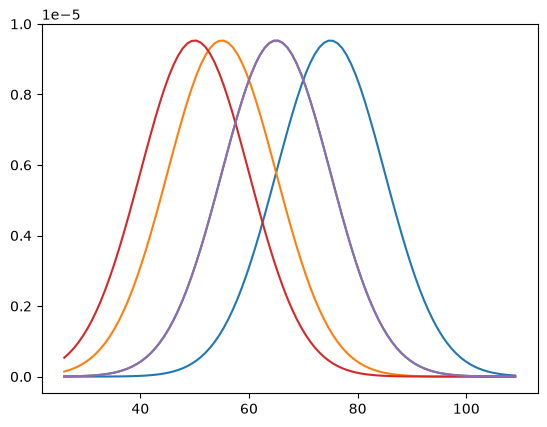

In [18]:
J = 5 # Number of data points to plot
X = df['age']
n = len(X)
# h_g = 1.06 * X.std() * n ** (-0.2) # Compute bandwidth
h_g = 10
x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, 100) # Create a grid to plot

gauss = lambda z: np.exp( -z**2/2)/np.sqrt(2*np.pi) # Gaussian kernel

f_hat = 0.0 # Storage for our kde plot
for i in range(J):
    K_i = gauss( (x_grid[:,None] - X[i])/h_g)/h_g # Broadcast the indicator
    f_i = np.sum(K_i,axis=1)/(2 * n * h_u) # Compute kde
    f_hat += f_i # Add f_i to the aggregate KDE
    plt.plot(x_grid,f_i)
plt.show()

<Axes: xlabel='age'>

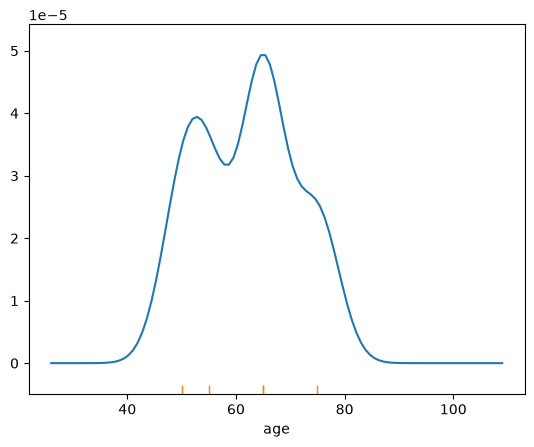

In [12]:
plt.plot(x_grid,f_hat) # Plot the aggregate KDE
sns.rugplot(X[:J]) # Rugplot to visualize data points

Plug-in Bandwidth Estimated is: 4.025331


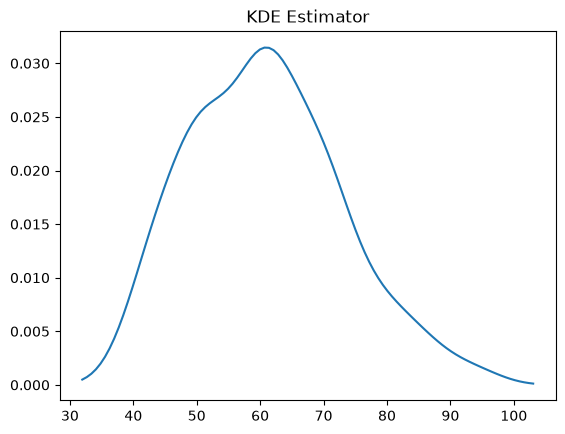

In [13]:
def kde_g(X, h = 0.0, plot = True):
    X = np.array(X)
    gauss = lambda z: np.exp( -z**2 / 2) / np.sqrt(2 * np.pi) # Gaussian kernel
    n = len(X)
    if h == 0.0:
        h = 1.06 * X.std() * n ** (-0.2) # Compute bandwidth
        print(f'Plug-in Bandwidth Estimated is: {h:2f}')
    x_grid = np.linspace( X.min()-2*h, X.max()+2*h, 100) # Create a grid to plot
    K = gauss( (x_grid[:,None] - X[None,:])/h)/h # Broadcast the indicator
    f_hat = K.mean(axis=1)
    if plot:
        plt.plot(x_grid,f_hat)
        plt.title('KDE Estimator')
        plt.show()
    return x_grid, f_hat, h

X = df['age']
x_grid, f_hat, h = kde_g(X)

<Axes: xlabel='age', ylabel='Density'>

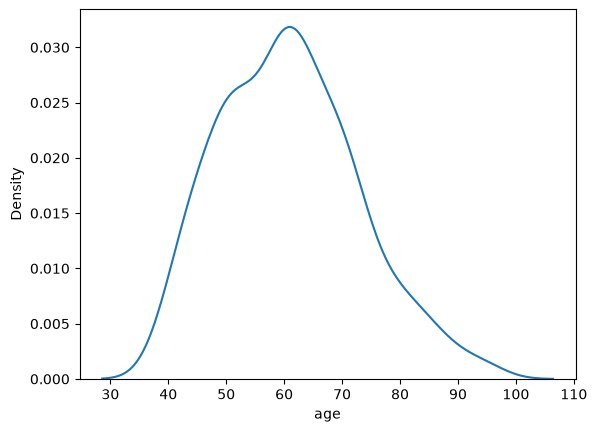

In [14]:
sns.kdeplot(X)

## Bias and consistency 

Plug-in Bandwidth Estimated is: 0.533487
Initial bandwidths is:0.53


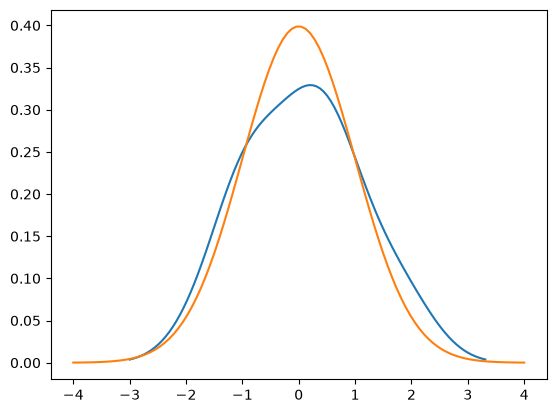

In [19]:
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 32

gauss = lambda z: np.exp(-z**2/2) / np.sqrt(2*np.pi)
grid = np.linspace( -4, 4, 100)
bell = gauss(grid)

samples = rng.standard_normal( size = n) 

# Initial estimate
x_grid, f_hat, h = kde_g(samples,plot=False)
plt.plot(x_grid,f_hat)
plt.plot(grid,bell)
print(f'Initial bandwidths is:{h:.2f}')

Fixed bandwidths is:0.50


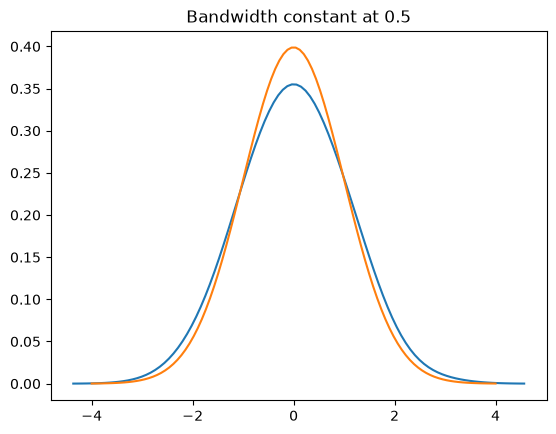

In [28]:
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 5000

gauss = lambda z: np.exp(-z**2/2) / np.sqrt(2*np.pi)
grid = np.linspace( -4, 4, 100)
bell = gauss(grid)

samples = rng.standard_normal( size = n) 

# Initial estimate
x_grid, f_hat, h = kde_g(samples,h=.5,plot=False)
plt.plot(x_grid,f_hat)
plt.title('Bandwidth constant at 0.5')
plt.plot(grid,bell)
print(f'Fixed bandwidths is:{h:.2f}')

Plug-in Bandwidth Estimated is: 0.191914
Floating bandwidths is:0.19


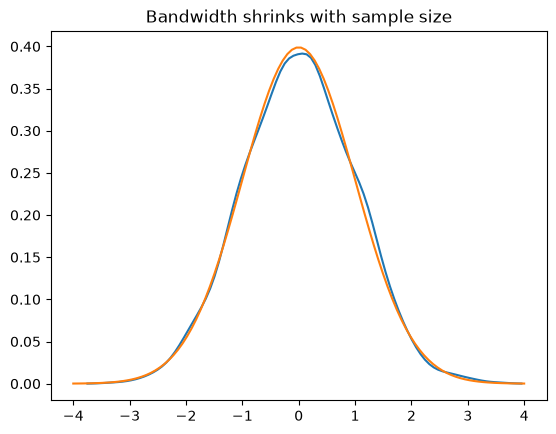

In [30]:
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 5000 # Sample Size

## Gaussian Curve:
gauss = lambda z: np.exp(-z**2/2) / np.sqrt(2*np.pi)
grid = np.linspace( -4, 4, 100)
bell = gauss(grid)

## KDE:
samples = rng.standard_normal( size = n) 
x_grid, f_hat, h = kde_g(samples,plot=False)
plt.plot(x_grid,f_hat)
plt.plot(grid,bell)
plt.title('Bandwidth shrinks with sample size')
print(f'Floating bandwidths is:{h:.2f}')

## What happened?
- We got an initial bandwidth estimate of about $.50$
- For the fixed simulation, the KDE is wrong: Bandwidth doesn't align with the true bell curve
- For the floating simulation, the KDE appoaches the truth: Bandwidth shrinks with the sample to $.19$
- KDE estimators are our first example of an estimator that is **biased** but **consistent**